Part 2: Pandas & Visualization – The Submission Delay Dataset

Phase 1: Data Preparation & Exploration

In [ ]:
!pip install --upgrade pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 59.4 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.3 which is incompatible.


In [ ]:
import pandas as pd
print(pd.__version__)

3.0.3


In [ ]:
df = pd.read_pickle("/content/sample_data/submission_data.pkl")

In [ ]:
#shape
print(df.shape)

(1618, 107)


In [ ]:
#column data types
print(df.dtypes)

Sno                   int64
Lecture               int64
StudentNo             int64
Total_Characters      int64
Total_Words           int64
                     ...   
x_96                float64
x_97                float64
x_98                float64
x_99                float64
x_100               float64
Length: 107, dtype: object


In [ ]:
#missing values
print(df.isnull().sum())

Sno                 0
Lecture             0
StudentNo           0
Total_Characters    0
Total_Words         0
                   ..
x_96                0
x_97                0
x_98                0
x_99                0
x_100               0
Length: 107, dtype: int64


In [ ]:
#creating target column
df['target'] = (df['Submission_Delay'] > 0).astype(int)


/tmp/ipykernel_4739/808053161.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['target'] = (df['Submission_Delay'] > 0).astype(int)


In [ ]:
#dropping submission delay column
df.drop('Submission_Delay', axis=1, inplace=True)

In [ ]:
#checking the columns values
print(df.describe())

               Sno      Lecture    StudentNo  Total_Characters  Total_Words  \
count  1618.000000  1618.000000  1618.000000       1618.000000  1618.000000   
mean    809.500000     5.744129    99.354141       2022.452410   323.750927   
min       1.000000     1.000000     1.000000         79.000000     4.000000   
25%     405.250000     3.000000    50.250000       1184.250000   196.000000   
50%     809.500000     6.000000   102.000000       1645.000000   267.000000   
75%    1213.750000     8.000000   146.000000       2492.750000   401.000000   
max    1618.000000    11.000000   195.000000      19689.000000  3078.000000   
std     467.220683     3.092880    55.024299       1360.556325   208.118919   

                  Submission_Time         x_01         x_02         x_03  \
count                        1618  1618.000000  1618.000000  1618.000000   
mean   2025-08-22 22:31:11.818912    -0.180653     0.247044     0.077171   
min           2025-08-01 12:27:27    -0.449366     0.055804 

In [ ]:
#in a cleaner way
stats = df.describe().T[['mean', 'std', 'min', 'max']]
print(stats)

                        mean          std       min       max
Sno                    809.5   467.220683       1.0    1618.0
Lecture             5.744129      3.09288       1.0      11.0
StudentNo          99.354141    55.024299       1.0     195.0
Total_Characters  2022.45241  1360.556325      79.0   19689.0
Total_Words       323.750927   208.118919       4.0    3078.0
...                      ...          ...       ...       ...
x_97                0.132666     0.063772  0.016857  0.319884
x_98               -0.313386     0.078424 -0.580676 -0.099421
x_99                0.147997     0.060437  0.032193  0.320424
x_100              -0.114386     0.068057 -0.300444 -0.016749
target               0.13597     0.342863       0.0       1.0

[107 rows x 4 columns]


In [ ]:
#dropping the target column
X = df.drop('target', axis=1)
y = df['target']

In [ ]:
#scaling using sklearn
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
#dropping non-numerical column
X_numerical = X.drop('Submission_Time', axis=1)

In [ ]:
#scaled finally
X_scaled = scaler.fit_transform(X_numerical)

In [ ]:
#checking the stats
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X_numerical.columns
)

In [ ]:
#final stats
scaled_stats = X_scaled_df.describe().T[['mean', 'std', 'min', 'max']]
print(scaled_stats)

                          mean       std       min        max
Sno              -7.026381e-17  1.000309 -1.730981   1.730981
Lecture           7.026381e-17  1.000309 -1.534361   1.699871
StudentNo         7.685104e-18  1.000309 -1.788020   1.738785
Total_Characters  8.782976e-18  1.000309 -1.428866  12.988811
Total_Words       2.415318e-17  1.000309 -1.536861  13.238107
...                        ...       ...       ...        ...
x_96             -8.431657e-16  1.000309 -3.595101   3.050032
x_97             -1.405276e-16  1.000309 -1.816560   2.936668
x_98              5.269785e-16  1.000309 -3.409320   2.729157
x_99              0.000000e+00  1.000309 -1.916716   2.853881
x_100            -3.513190e-17  1.000309 -2.734710   1.435081

[105 rows x 4 columns]


Phase-2: Feature Correlation & Heatmaps

In [ ]:
#correlation with the target
correlations = df.corr()['target'].drop('target')

In [ ]:
#absolute correlations
correlations_abs = correlations.abs()

In [ ]:
top_15 = correlations_abs.sort_values(
    ascending=False
).head(15)

In [ ]:
#printing top 15 features
print(top_15)

x_04                0.065493
x_05                0.060733
x_54                0.057554
Total_Words         0.055027
Total_Characters    0.053349
x_74                0.047948
x_84                0.046002
x_19                0.044380
x_52                0.043613
x_25                0.039566
x_100               0.039395
x_38                0.036348
Sno                 0.035988
x_02                0.035862
x_86                0.035243
Name: target, dtype: float64


In [ ]:
#extracting the column names of top 15 features
top_15_index= list(top_15.index)

In [ ]:
#making the dataframe of only those top 15 features
top_15_df=df[top_15_index+['target']]

In [ ]:
#correlations of top 15 features with only numeric values
heatmap_df = top_15_df.corr(numeric_only=True)

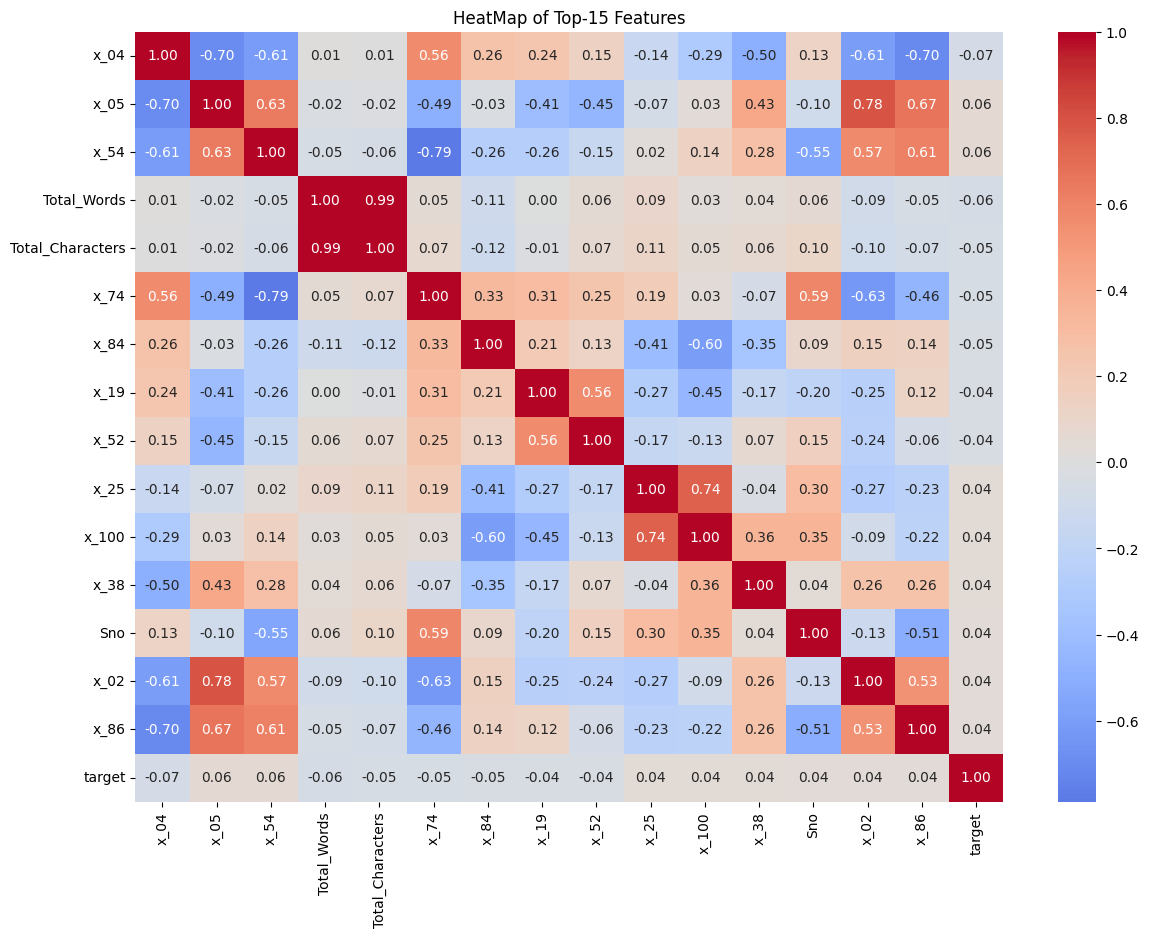

In [ ]:
#plotting heatmap
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(14,10))
sns.heatmap(heatmap_df,annot=True,cmap="coolwarm",center=0,fmt=".2f")
plt.title("HeatMap of Top-15 Features")
plt.show()

Phase 3: Dimensionality Reduction (UMAP vs. t-SNE)

In [ ]:
!pip install umap-learn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#importing t-SNE
from sklearn.manifold import TSNE
#importing umap
import umap.umap_ as umap

Text(0, 0.5, 't-SNE Component 2')

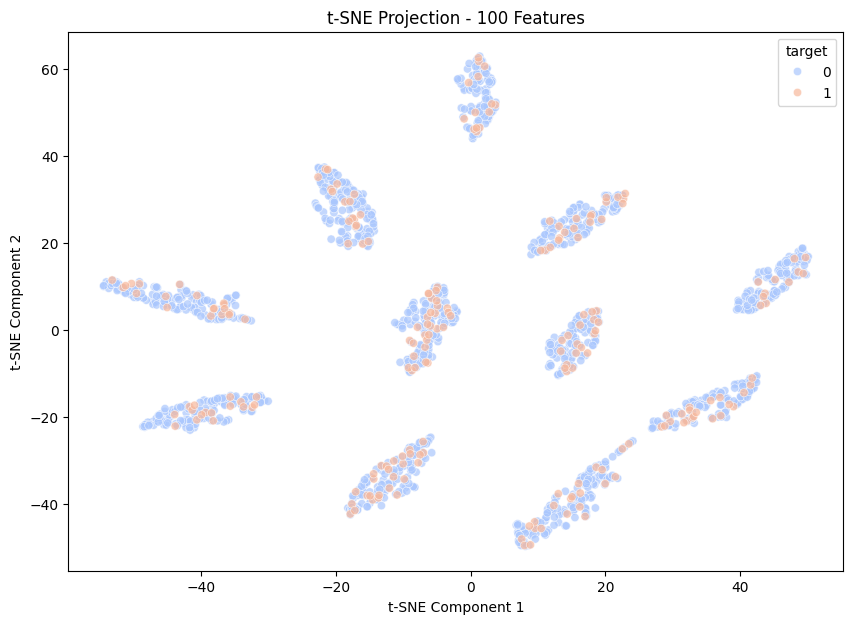

In [ ]:
#applying t-SNE on 100 Features
#converting 100-D into 2-D space
tsne= TSNE(n_components=2,random_state=42)
X_tsne=tsne.fit_transform(X_scaled)
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_tsne[:,0],y=X_tsne[:,1],hue=y,palette="coolwarm",alpha=0.7)
plt.title("t-SNE Projection - 100 Features")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


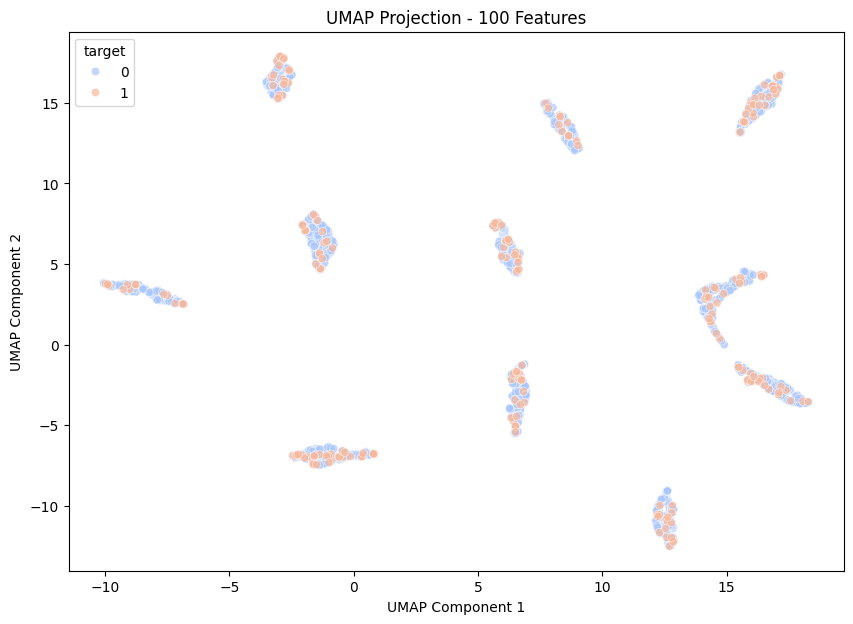

In [ ]:
#applying UMAP on 100 Features
#converting 100-D into 2-D space
umap_model = umap.UMAP(n_components=2,random_state=42)
X_umap = umap_model.fit_transform(X_scaled)
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_umap[:, 0],y=X_umap[:, 1],hue=y,palette="coolwarm",alpha=0.7)
plt.title("UMAP Projection - 100 Features")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.show()

In [ ]:
X_top15=X_scaled_df[top_15_index]

In [ ]:
X_umap_top15 = umap_model.fit_transform(X_top15)

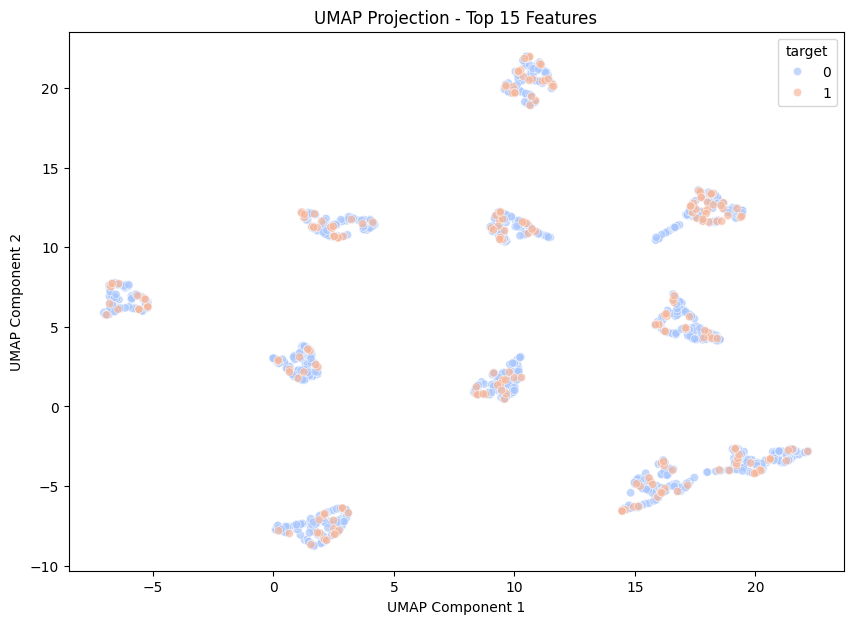

In [ ]:
#applying UMAP on 15 Features
#converting 15-D into 2-D
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_umap_top15[:, 0],y=X_umap_top15[:, 1],hue=y,palette="coolwarm",alpha=0.7
)
plt.title("UMAP Projection - Top 15 Features")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.show()

Part 3: Predictive Modeling & Evaluation

In [ ]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    roc_auc_score
)

In [ ]:
#using top 15 features only
X = X_top15
y = df['target']

In [ ]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
#models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Support Vector Machine (SVC)": SVC(
        probability=True
    ),

    "Random Forest Classifier": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

In [ ]:
#results
results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    report = classification_report(y_test,y_pred,output_dict=True)
    accuracy = accuracy_score(y_test, y_pred)
    precision = report['1']['precision']
    recall = report['1']['recall']
    f1 = report['1']['f1-score']
    auc = roc_auc_score(y_test, y_prob)
    results.append([model_name,accuracy,precision,recall,f1,auc])

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [ ]:
#required table
results_df = pd.DataFrame(results,columns=["Model","Accuracy","Precision (Class 1)","Recall (Class 1)","F1-Score (Class 1)","AUC_ROC"])
print(results_df)

                          Model  Accuracy  Precision (Class 1)  \
0           Logistic Regression  0.864198             0.000000   
1  Support Vector Machine (SVC)  0.864198             0.000000   
2      Random Forest Classifier  0.919753             0.909091   

   Recall (Class 1)  F1-Score (Class 1)   AUC_ROC  
0          0.000000            0.000000  0.706088  
1          0.000000            0.000000  0.887662  
2          0.454545            0.606061  0.984253  


In [ ]:
#all features
X_all = X_scaled_df
y = df['target']

In [ ]:
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(X_all,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
all_results = []

for model_name, model in models.items():
    model.fit(X_train_all, y_train_all)
    y_pred_all = model.predict(X_test_all)
    y_prob_all = model.predict_proba(X_test_all)[:, 1]
    report = classification_report(y_test_all,y_pred_all,output_dict=True)
    accuracy = accuracy_score(y_test_all, y_pred_all)
    precision = report['1']['precision']
    recall = report['1']['recall']
    f1 = report['1']['f1-score']
    auc = roc_auc_score(y_test_all, y_prob_all)
    all_results.append([model_name,accuracy,precision,recall,f1,auc])

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#required table
all_results_df = pd.DataFrame(all_results,columns=["Model","Accuracy","Precision (Class 1)","Recall (Class 1)","F1-Score (Class 1)","AUC_ROC"])
print(all_results_df)

                          Model  Accuracy  Precision (Class 1)  \
0           Logistic Regression  0.867284                 1.00   
1  Support Vector Machine (SVC)  0.864198                 0.00   
2      Random Forest Classifier  0.876543                 0.75   

   Recall (Class 1)  F1-Score (Class 1)   AUC_ROC  
0          0.022727            0.044444  0.870455  
1          0.000000            0.000000  0.834334  
2          0.136364            0.230769  0.899107  
